### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing and Cleaning Dataframe

In [2]:
#Importing Dataframe

df = pd.read_excel("FEV-data-Excel.xlsx")
print(df.isnull().sum())

Car full name                             0
Make                                      0
Model                                     0
Minimal price (gross) [PLN]               0
Engine power [KM]                         0
Maximum torque [Nm]                       0
Type of brakes                            1
Drive type                                0
Battery capacity [kWh]                    0
Range (WLTP) [km]                         0
Wheelbase [cm]                            0
Length [cm]                               0
Width [cm]                                0
Height [cm]                               0
Minimal empty weight [kg]                 0
Permissable gross weight [kg]             8
Maximum load capacity [kg]                8
Number of seats                           0
Number of doors                           0
Tire size [in]                            0
Maximum speed [kph]                       0
Boot capacity (VDA) [l]                   1
Acceleration 0-100 kph [s]      

In [3]:
#Cleaning

df["Type of brakes"] = df["Type of brakes"].fillna(df["Type of brakes"].mode()[0])
df["Permissable gross weight [kg]"] = df["Permissable gross weight [kg]"].fillna(df["Permissable gross weight [kg]"].median())
df["Maximum load capacity [kg]"] = df["Maximum load capacity [kg]"].fillna(df["Maximum load capacity [kg]"].median())
df["Boot capacity (VDA) [l]"] = df["Boot capacity (VDA) [l]"].fillna(df["Boot capacity (VDA) [l]"].median())
df["Acceleration 0-100 kph [s]"] = df["Acceleration 0-100 kph [s]"].fillna(df["Acceleration 0-100 kph [s]"].median())
df["mean - Energy consumption [kWh/100 km]"] = df["mean - Energy consumption [kWh/100 km]"].fillna(df["mean - Energy consumption [kWh/100 km]"].median())
print(df.isnull().sum())
df.head()

Car full name                             0
Make                                      0
Model                                     0
Minimal price (gross) [PLN]               0
Engine power [KM]                         0
Maximum torque [Nm]                       0
Type of brakes                            0
Drive type                                0
Battery capacity [kWh]                    0
Range (WLTP) [km]                         0
Wheelbase [cm]                            0
Length [cm]                               0
Width [cm]                                0
Height [cm]                               0
Minimal empty weight [kg]                 0
Permissable gross weight [kg]             0
Maximum load capacity [kg]                0
Number of seats                           0
Number of doors                           0
Tire size [in]                            0
Maximum speed [kph]                       0
Boot capacity (VDA) [l]                   0
Acceleration 0-100 kph [s]      

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
1,Audi e-tron 50 quattro,Audi,e-tron 50 quattro,308400,313,540,disc (front + rear),4WD,71.0,340,...,3040.0,670.0,5,5,19,190,660.0,6.8,150,23.80
2,Audi e-tron S quattro,Audi,e-tron S quattro,414900,503,973,disc (front + rear),4WD,95.0,364,...,3130.0,565.0,5,5,20,210,660.0,4.5,150,27.55
3,Audi e-tron Sportback 50 quattro,Audi,e-tron Sportback 50 quattro,319700,313,540,disc (front + rear),4WD,71.0,346,...,3040.0,640.0,5,5,19,190,615.0,6.8,150,23.30
4,Audi e-tron Sportback 55 quattro,Audi,e-tron Sportback 55 quattro,357000,360,664,disc (front + rear),4WD,95.0,447,...,3130.0,670.0,5,5,19,200,615.0,5.7,150,23.85


## Task 1 :

###  A customer has a budget of 350,000 PLN and wants an EV with a minimum range of 400 km

#### Approach:
##### In this task, I have first examined the dataset to understand the available columns related to price, range, and battery capacity. Then I have filtered the dataset to include only electric vehicles priced below 350,000 PLN and having a minimum driving range of 400 km. Also calculated the average battery capacity for each manufacturer to compare their offerings.

In [4]:
#1.a
#Filtering out EV's that meet the above criteria

filtered_ev = df[(df["Minimal price (gross) [PLN]"] <= 350000) & (df["Range (WLTP) [km]"] >= 400)]
filtered_ev.head()


,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
8,BMW iX3,BMW,iX3,282900,286,400,disc (front + rear),2WD (rear),80.0,460,...,2725.0,540.0,5,5,19,180,510.0,6.8,150,18.80
15,Hyundai Kona electric 64kWh,Hyundai,Kona electric 64kWh,178400,204,395,disc (front + rear),2WD (front),64.0,449,...,2170.0,485.0,5,5,17,167,332.0,7.6,100,15.40
18,Kia e-Niro 64kWh,Kia,e-Niro 64kWh,167990,204,395,disc (front + rear),2WD (front),64.0,455,...,2230.0,493.0,5,5,17,167,451.0,7.8,100,15.90
20,Kia e-Soul 64kWh,Kia,e-Soul 64kWh,160990,204,395,disc (front + rear),2WD (front),64.0,452,...,1682.0,498.0,5,5,17,167,315.0,7.9,100,15.70


In [5]:
#1.b
#Grouping them by the manufacturer

group_by_make = filtered_ev.groupby("Make")
count_by_make = group_by_make.size().reset_index(name="EV Count").sort_values(by="EV Count",ascending=False).reset_index(drop=True)
count_by_make

,Make,EV Count
0,Volkswagen,3
1,Tesla,3
2,Kia,2
3,Hyundai,1
4,BMW,1
5,Audi,1
6,Mercedes-Benz,1


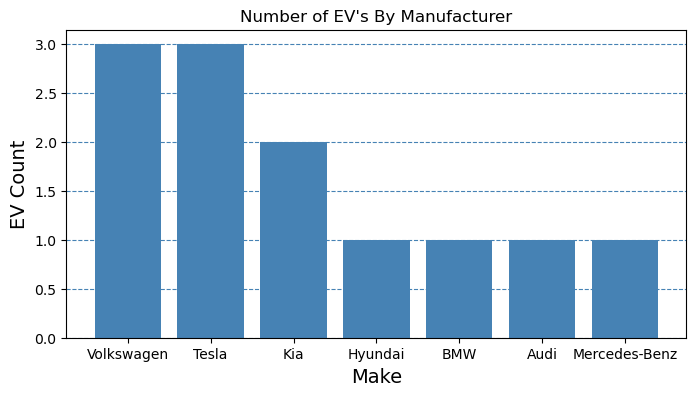

In [6]:
#Visual represenattion

plt.figure(figsize=(8, 4))
plt.bar(count_by_make["Make"], count_by_make["EV Count"], color="steelblue")
plt.title("Number of EV's By Manufacturer")
plt.xlabel("Make", fontsize=14)
plt.ylabel("EV Count", fontsize=14)
plt.grid(axis="y", linestyle="--",color="steelblue")
plt.show()

In [7]:
#1.c
#Calculating the average battery capacity for each manufacturer

avg_battery_cap = group_by_make["Battery capacity [kWh]"].mean().sort_values(ascending=False).reset_index()
avg_battery_cap


,Make,Battery capacity [kWh]
0,Audi,95.000000
1,BMW,80.000000
2,Mercedes-Benz,80.000000
3,Volkswagen,70.666667
4,Tesla,68.000000
5,Hyundai,64.000000
6,Kia,64.000000


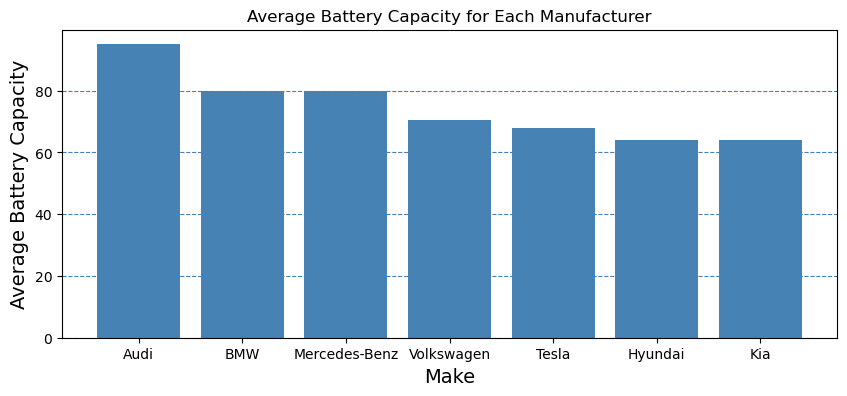

In [8]:
#Visual Representation

plt.figure(figsize=(10, 4))
plt.bar(avg_battery_cap["Make"], avg_battery_cap["Battery capacity [kWh]"], color="steelblue")
plt.title("Average Battery Capacity for Each Manufacturer")
plt.xlabel("Make", fontsize=14)
plt.ylabel("Average Battery Capacity", fontsize=14)
plt.grid(axis="y", linestyle="--",color="steelblue")
plt.show()

## Task 2 :

### Find the outliers in the mean - Energy consumption [kWh/100 km] column.

#### Approach:
##### In this task, I have analyzed the mean energy consumption values to identify unusual observations. I have used the Interquartile Range(IQR) method and boxplot for visualization, to calculate the normal range of energy consumption.

In [9]:
#So first we will check through IQR Calculation

Q1 = df["mean - Energy consumption [kWh/100 km]"].quantile(0.25)
Q3 = df["mean - Energy consumption [kWh/100 km]"].quantile(0.75)
IQR = Q3 - Q1

#Lower and Upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Checking Outliers
outliers = df[(df["mean - Energy consumption [kWh/100 km]"] < lower_bound) | (df["mean - Energy consumption [kWh/100 km]"] > upper_bound)]
print("Outliers in energy consumption:")
if outliers.empty:
    print("No outliers detected in energy consumption using IQR method.")


Outliers in energy consumption:
No outliers detected in energy consumption using IQR method.


#### Boxplot

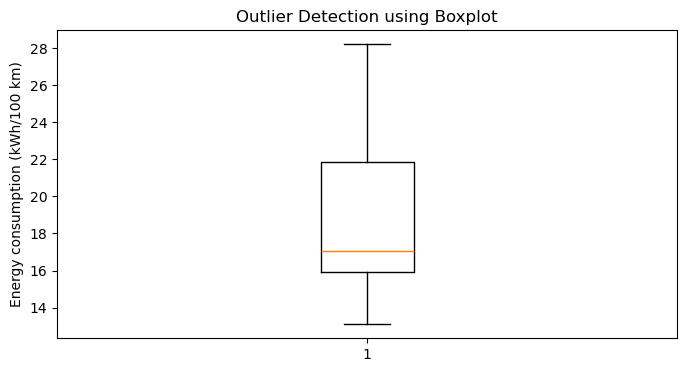

In [10]:
#Now we will use Boxplot for Visual representation and to double check outliers

plt.figure(figsize=(8, 4))
plt.boxplot(df["mean - Energy consumption [kWh/100 km]"])
plt.ylabel("Energy consumption (kWh/100 km)")
plt.title("Outlier Detection using Boxplot")
plt.show()


## Task 3:

### Manager wants to know if there's a strong relationship between Battery capacity and Range.

#### Approach:
##### In this task, I have explored the relationship between battery capacity and driving range. I have created a scatter plot to visually observe changes in battery capacity that affect the vehicle range.

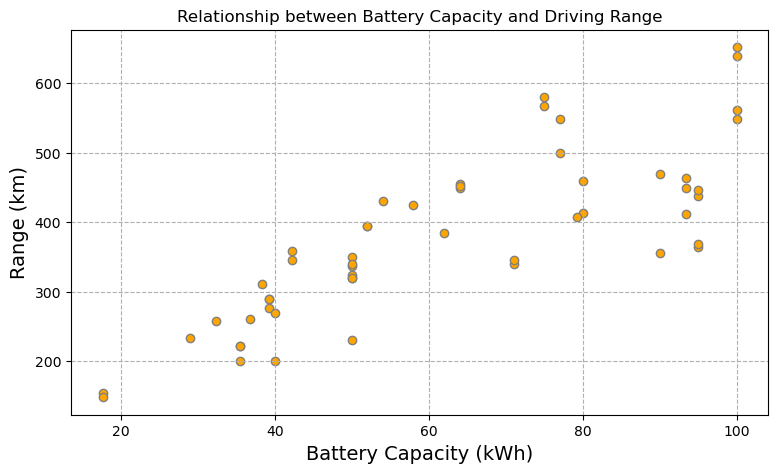




Correlation is: 0.81


In [11]:
#3.a
#Create a suitable plot to visualize

plt.figure(figsize=(9, 5))
plt.scatter(df["Battery capacity [kWh]"],df["Range (WLTP) [km]"], color="orange", edgecolor="grey")
plt.xlabel("Battery Capacity (kWh)",fontsize=14)
plt.ylabel("Range (km)",fontsize=14)
plt.title("Relationship between Battery Capacity and Driving Range")
plt.grid(True, linestyle="--")
plt.show()


correlation = df["Battery capacity [kWh]"].corr(df["Range (WLTP) [km]"])
print(f"\n\n\nCorrelation is: {correlation:.2f}")

### 3.b) Highlight any insights

- From the plot diagram it is clear that electric vehicles with larger battery capacities gets a longer driving range.
- This means that if we increase the battery size helps the car travel further more on a single charge.
- Also we can note that battery capacity is not the only factor affecting range, since some of the vehicles with lower battery capacity were also able    to achieve good range due to better efficiency.
- Vehicle weight, design and energy efficiency also play an important role for acheiving better range for longer drive.


## Task 4:

### Build an EV recommendation class

##### The class should allow users to input their budget, desired range, and battery capacity. The class should then return the top three EVsmatching their criteria.

In [17]:
#Creating and defining Class
class EVRecommender:
    def __init__(self, df):
        self.df = df

#Defined User Inputs
    def user_preferences(self):
        budget = float(input("Enter your maximum budget (PLN): "))
        min_range = float(input("Enter minimum driving range (km): "))
        min_battery = float(input("Enter minimum battery capacity (kWh): "))
        return budget, min_range, min_battery

#Defining recommendation based on user inputs
    def recommend_evs(self):
        budget, min_range, min_battery = self.user_preferences()
        suitable_evs = self.df[
            (self.df["Minimal price (gross) [PLN]"] <= budget) & 
            (self.df["Range (WLTP) [km]"] >= min_range) &
            (self.df["Battery capacity [kWh]"] >= min_battery)
            ]
        
#Extracting Top Three based on user preference
        top_three = suitable_evs.sort_values(by="Range (WLTP) [km]", ascending=False).head(3)
        return top_three[["Make", "Model", "Minimal price (gross) [PLN]", "Range (WLTP) [km]", "Battery capacity [kWh]"]]


ev_recommender = EVRecommender(df)
recommended_evs = ev_recommender.recommend_evs()
recommended_evs

Enter your maximum budget (PLN):  450000
Enter minimum driving range (km):  400
Enter minimum battery capacity (kWh):  50


,Make,Model,Minimal price (gross) [PLN],Range (WLTP) [km],Battery capacity [kWh]
42,Tesla,Model S Long Range Plus,368990,652,100.0
43,Tesla,Model S Performance,443990,639,100.0
40,Tesla,Model 3 Long Range,235490,580,75.0


## Task 5: 

#### Inferential Statistics – Hypothesis Testing: Test whether there is a significant difference in the average Engine power [KM] of vehicles manufactured by two leading manufacturers i.e. Tesla and Audi

In [15]:
#Task 5 : Inferential Statistics – Hypothesis Testing

from scipy.stats import ttest_ind

#Extracting engine power values for Tesla and Audi
tesla_power = df[df["Make"] == "Tesla"]["Engine power [KM]"].dropna()
audi_power = df[df["Make"] == "Audi"]["Engine power [KM]"].dropna()

#Two-sample T-Test
t_stat, p_value = ttest_ind(tesla_power, audi_power, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a statistically significant difference in engine power between Tesla and Audi vehicles.")
else:
    print("No statistically significant difference in engine power was observed between Tesla and Audi vehicles.")




T-statistic: 1.79
P-value: 0.107
No statistically significant difference in engine power was observed between Tesla and Audi vehicles.


### Insights:

- The average engine power of 'Tesla' and 'Audi' electric vehicles is very similar.
- The p-value is greater than 0.05, meaning the difference observed in the data is not strong enough to be considered statistically significant.
- This suggests that both manufacturers focus on power output in their EV Vehicles.


### Recommendations:

- Since the statistical test shows no significant difference in average engine power between 'Tesla' and 'Audi', just engine power should not be the      deciding factor while choosing between these two brands.
- Customers should compare other aspects such as driving range, battery capacity, charging speed, pricing, and overall vehicle features since engine      power seems almost same.


### Conclusion:

- The Two-sample T-Test results states that the difference in average engine power between 'Tesla' and 'Audi' EV's are not statistically significant.
- As the p-value is greater than significance level of 0.05, the null hypothesis is not rejected. This states that on average 'Tesla' and 'Audi'          provide similar engine power.

## Task 6:

#### Video Explanation Link:

##### https://www.loom.com/share/151dbf04452744ceb7c33b9f11a1c782